# Target Tracking Applications
## 1. Continuous-time- linear state-space model simulation

An important use case of Kalman Filter (KF).

It must be able to predict the future location of the target based on KF estimates and measurements.

Usually, the input signal $u(t)$ is not known.

We assume some behaviours like:

target moves in straight-line, in circles or is staionary,

to approximate target dynamics.

In [58]:
% This loads the Octave control-systems "package," which implements the "ss" and "lsim" commands.
pkg load control

## Nearly Constant Position (NCP) Model

This model assumes the object does not move significantly; its position may change slowly due to small random disturbances.

### State vector
$$
x(t) = 
\begin{bmatrix}
\xi(t) \\
\eta(t)
\end{bmatrix}.
$$

### Continuous-time state equation
$$
\dot{x}(t) = 
\underbrace{
\begin{bmatrix}
0 & 0 \\
0 & 0
\end{bmatrix}
}_{A}
x(t) + w(t).
$$

Here, $w(t)$ is the (unknown) process noise input.

### Measurement equation
$$
z(t) =
\underbrace{
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
}_{C}
x(t) + v(t)
$$

, where $v(t)$ is the (unknown) measurement noise.

### Simulating Continuous-Time State-Space Models in Octave

Octave (control package) provides:

- `ss()` → create continuous-time state-space model from $A,B,C,D$
- `lsim()` → simulate a state-space model response for a given input and initial state

**Workflow**

1. Define $A,B,C,D$ in Octave workspace
   
2. Create state-space object  
   ```octave
   sys = ss(A,B,C,D);
   
   
3. Define time vector + input $u(t)$

   t = 0:Ts:Tfinal;
   
   u = < your input sequence >;
   
4. Simulate

   [y,t,x] = lsim(sys,u,t,x0);
   
   $y(t)$ → model output

   $x(t)$ → state trajectory

   $x_0$ (optional) → initial state vector

In [59]:
% Define the NCP model
A = zeros(2); Bw = eye(2);
C = eye(2);   D = zeros(2);
ncp = ss(A,Bw,C,D);

### Note on `ss(A, Bw, C, D)` for NCP model

In NCP there is **no known control input** driving the state. The object only moves due to random disturbances.  
Therefore instead of `B u(t)` we model:

$$
\dot{x}(t) = A x(t) + B_w w(t)
$$

where:

- $w(t)$ is process noise
- $B_w$ maps noise into the state dynamics

So in Octave/MATLAB:

```matlab
sys = ss(A, Bw, C, D);


In [60]:
%% Simulate NCP model
randn("state", 0);              % Fix random seed for reproducibility

dt   = 0.1;
N    = 1000;
t    = (0:N-1)*dt;

w    = 0.05 * randn(2, N);      % process noise
v    = 0.01 * randn(2, N);      % measurement noise

z    = lsim(ncp, w', t) + v';   % measured output


In [61]:
graphics_toolkit('gnuplot');

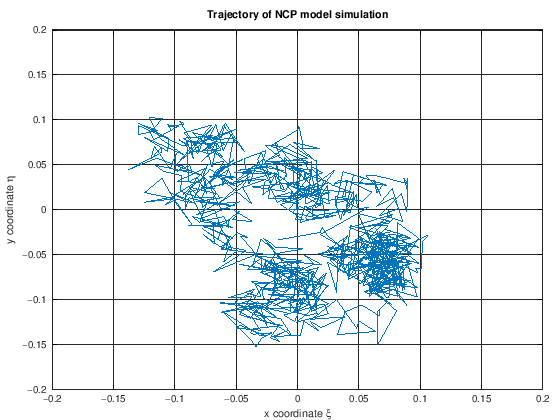

In [62]:
% Plot the simulation output
plot(z(:,1),z(:,2));
xlabel('x coordinate \xi');
ylabel('y coordinate \eta');
title('Trajectory of NCP model simulation');
grid on

In [63]:
% Display the final coordinate of the trajectory
z(end,:)



ans =

  -0.015459  -0.033355



In [64]:
printf("NCP final eta = %.3f\n", zncp(end,2));



error: invalid use of 'end': may only be used to index existing value


## Nearly Constant Velocity (NCV) Model

We assume an object moves with almost constant velocity, but small unknown forces perturb it.

### State vector
$$
x(t) = 
\begin{bmatrix}
\xi(t) \\
\dot{\xi}(t) \\
\eta(t) \\
\dot{\eta}(t)
\end{bmatrix}.
$$

### Continuous-time state equation
$$
\dot{x}(t) = 
\underbrace{
\begin{bmatrix}
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0
\end{bmatrix}
}_{A}
x(t)
+
\underbrace{
\begin{bmatrix}
0 & 0 \\
1 & 0 \\
0 & 0 \\
0 & 1
\end{bmatrix}
}_{w(t)}
\widetilde{w}(t).
$$

Here, $\widetilde{w}(t)$ is a random process noise input.

### Measurement equation
$$
z(t) =
\underbrace{
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0
\end{bmatrix}
}_{C}
x(t) + v(t)
$$
, where  $ v(t)$ is a random measurement noise.

In [65]:
% Define the NCV model
A = [0 1 0 0; 0 0 0 0 ; ...
     0 0 0 1; 0 0 0 0 ];
Bw = [0 0; 1 0; 0 0; 0 1];
C = [1 0 0 0; 0 0 1 0];
D = zeros(2);
ncv = ss(A, Bw, C, D);


### Note on `ss(A, Bw, C, D)` for NCV model

The NCV model includes velocity states, but there is still **no known deterministic control input**.  
State changes occur due to random external forces that influence the velocity terms.

Here, $B_w$ maps the process noise vector $w(t)$ into the dynamics.  
These random accelerations integrate into velocity and then into position.

So:

```matlab
ncv = ss(A, Bw, C, D);


In [66]:
%% Simulate NCV model
randn("state", 0);              % Fix random seed for reproducibility

dt   = 0.1;
N    = 1000;
t    = (0:N-1)*dt;

w    = 0.05 * randn(2, N);      % process noise
v    = 0.01 * randn(2, N);      % measurement noise

z    = lsim(ncv, w', t) + v';   % measured output


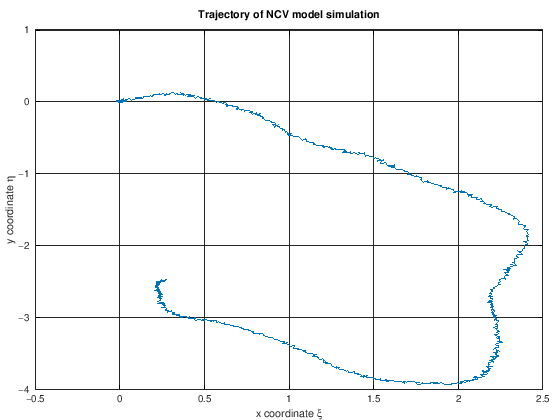

In [67]:
%% Plot NCV simulation trajectory
plot(z(:,1), z(:,2));
xlabel('x coordinate \xi');
ylabel('y coordinate \eta');
title('Trajectory of NCV model simulation');
grid on;


In [68]:
% Display the final coordinate of the trajectory
z(end,:)



ans =

   0.2391  -2.5050



## Coordinated Turn Model (Continuous-Time)

We assume motion in 2D with constant speed magnitude and constant turn-rate $ \Omega $.  
$ \Omega > 0 $ → CCW turn, $ \Omega < 0 $ → CW turn.

### State
$$
x(t)=
\begin{bmatrix}
\xi(t)\\
\dot{\xi}(t)\\
\eta(t)\\
\dot{\eta}(t)
\end{bmatrix}
$$

### Dynamics
$$
\dot{x}(t)= A\,x(t) + G\,\tilde w(t)
$$

$$
A=
\begin{bmatrix}
0 & 1 & 0 & 0 \\
0 & 0 & 0 & -\Omega \\
0 & 0 & 0 & 1 \\
0 & \Omega & 0 & 0
\end{bmatrix},
\qquad
G=
\begin{bmatrix}
0 & 0 \\
1 & 0 \\
0 & 0 \\
0 & 1
\end{bmatrix}
$$

- $\tilde w(t)$ is a 2×1 white-noise acceleration input (often modeled with spectral density $Q_c$).
- Cross-coupling via $\Omega$ rotates the velocity vector → coordinated circular turn when noise is zero.

### Measurement
$$
z(t)=C\,x(t)+v(t), \qquad
C=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 0 & 1 & 0
\end{bmatrix}
$$


In [69]:
% Define the CT model
W  = 0.01; % Value of Omega
A  = [0 1 0 0; 0 0 0 -W; ...
      0 0 0 1; 0 W 0 0];
Bw = [0 0; 1 0; 0 0; 0 1];
C  = [1 0 0 0; 0 0 1 0]; 
D  = zeros(2);
ct = ss(A,Bw,C,D);

### Note on `ss(A, G, C, D)` for CT model

In the Coordinated Turn (CT) model, there is also **no known external control input**.  
The circular motion arises from the internal turn–rate parameter $\Omega$, not from $u(t)$.

The continuous–time dynamics:

$$
\dot{x}(t) = A x(t) + G \tilde{w}(t)
$$

- $\Omega$ defines the constant turn rate
- $\tilde{w}(t)$ is a 2×1 white-noise acceleration disturbance
- stochastic influence enters through $G$

Therefore in Octave/MATLAB representation:

```matlab
sys = ss(A, G, C, D);


In [70]:
%% Simulate CT model
randn("state", 0);              % Fix random seed for reproducibility

dt   = 0.1;
N    = 1000;
t    = (0:N-1)*dt;

w    = 0.01 * randn(2, N);      % process noise (smaller)
v    = 0.001 * randn(2, N);     % measurement noise (very small)

z    = lsim(ct, w', t) + v';    % measured output


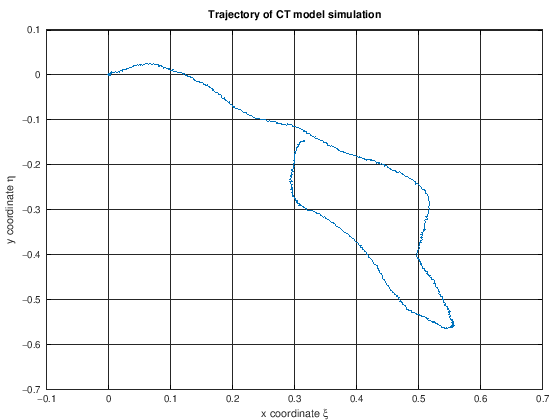

In [71]:
% Plot the output of the CT model
plot(z(:,1),z(:,2));
xlabel('x coordinate \xi');
ylabel('y coordinate \eta');
title('Trajectory of CT model simulation');
grid on

In [72]:
% Display the final coordinate of the trajectory
z(end,:)



ans =

   0.3135  -0.1487



## 2. Discrete-time state space model 

#### Discrete-Time State-Space Simulation (NCV/NCP/NCA/CT)

This section will implement the same kinematic models in discrete-time form:

- Same state definitions as continuous models
- Discrete state transition matrices
- Process noise discretization
